# PCA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif, RFE, RFECV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA

In [2]:
dataset = "C:/Users/tamer/Documents/PhD/ML/enhanced_metabolome.xlsx"
df = pd.read_excel(dataset, sheet_name = 'Paul')

In [3]:
df.shape

(24, 1295)

In [4]:
df['Class'].value_counts()

Class
LN    6
LP    6
SN    6
SP    6
Name: count, dtype: int64

In [5]:
def encodage(df):
    code = {
    'LP' : 'Lemon inoculated',
    'SP' : 'Orange inoculated',
    'LN' : 'Lemon control',
    'SN' : 'Orange control'
}
# Appliquer ce dictionnaire aux colonnes du dataset, avec la fonction map
    for col in df.select_dtypes('object'):
        df[col] = df[col].map(code)

    return df


def preprocessing(df):
    df = encodage(df)

    X = df.drop(['Class'], axis = 1)
    y = df['Class']

    # compter le nombre d'échantillons restants dans le dataset après avoir été inputé
    print(y.value_counts())

    return X, y

In [6]:
X, y = preprocessing(df)
# Principalement encoder les classes

Class
Lemon control        6
Lemon inoculated     6
Orange control       6
Orange inoculated    6
Name: count, dtype: int64


In [7]:
import numpy as np
from matplotlib.patches import Ellipse

def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    # Remove accidental duplicates from kwargs
    kwargs.pop("n_std", None)
    kwargs.pop("confidence", None)

    x = np.asarray(x)
    y = np.asarray(y)

    if x.size < 2:
        return

    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)

    mean_x, mean_y = x.mean(), y.mean()
    ell = Ellipse(
        (mean_x, mean_y),
        width=width,
        height=height,
        angle=theta,
        fill=False,
        **kwargs
    )
    ax.add_patch(ell)
    return ell

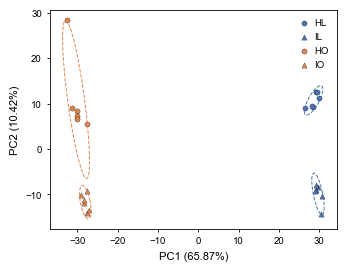

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

# --------------------------------------------------
# GLOBAL GRAPHIC PARAMETERS (Single column optimized)
# --------------------------------------------------
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,              # base text
    "axes.labelsize": 8,         # PC1 / PC2
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# --------------------------------------------------
# PCA PIPELINE
# --------------------------------------------------
log2_transformer = FunctionTransformer(lambda x: np.log2(x + 1))

model = make_pipeline(
    log2_transformer,
    StandardScaler(),
    PCA(n_components=2)
)

X_reduced = model.fit_transform(X)
pca = model.named_steps['pca']

# --------------------------------------------------
# FIGURE SIZE (85 mm width)
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(3.35, 2.6))

# --------------------------------------------------
# VISUAL ENCODING
# --------------------------------------------------
color_map = {
    "Lemon control": "#4c73b2",
    "Lemon inoculated": "#4c73b2",
    "Orange control": "#de8552",
    "Orange inoculated": "#de8552"
}

marker_map = {
    "Lemon control": "o",
    "Orange control": "o",
    "Lemon inoculated": "^",
    "Orange inoculated": "^"
}

classes = sorted(y.unique())

label_map = {
    "Lemon control": "HL",
    "Lemon inoculated": "IL",
    "Orange control": "HO",
    "Orange inoculated": "IO"
}

# --------------------------------------------------
# SCATTER + ELLIPSES
# --------------------------------------------------
for cls in classes:

    mask = (y == cls)
    xg = X_reduced[mask, 0]
    yg = X_reduced[mask, 1]

    ax.scatter(
        xg,
        yg,
        color=color_map[cls],
        marker=marker_map[cls],
        label=label_map[cls],
        s=14,                # ↓ réduit
        edgecolor="black",
        linewidth=0.2        # ↓ plus fin
    )
    
    confidence_ellipse(
        xg,
        yg,
        ax,
        n_std=2.0,
        edgecolor=color_map[cls],
        linewidth=0.7,       # ↓ plus fin
        linestyle="--",
        alpha=1
    )

# --------------------------------------------------
# AXES
# --------------------------------------------------
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.6)

ax.tick_params(direction='out', length=2, width=0.6)

# --------------------------------------------------
# LEGEND
# --------------------------------------------------
leg = ax.legend(
    frameon=False,
    loc="best",
    handlelength=1.2,
    handletextpad=0.4
)

# --------------------------------------------------
# LAYOUT
# --------------------------------------------------
plt.tight_layout(pad=0.4)

# --------------------------------------------------
# EXPORT
# --------------------------------------------------
plt.savefig(
    "C:/Users/tamer/Documents/PhD/ML/PCA/PCA_global.pdf",
    bbox_inches="tight",
    transparent=True
)

plt.savefig(
    "C:/Users/tamer/Documents/PhD/ML/PCA/PCA_global.tif",
    dpi=600,
    bbox_inches="tight",
    format="tiff"
)

plt.show()

In [9]:
stop

NameError: name 'stop' is not defined

In [ ]:
# Get metrics from PCA
pca = model.named_steps['pca'] #Identifier le modèle depuis le pipeline
pca.components_.shape

In [ ]:
#Identifier la var expliquée component par component
print(np.cumsum(pca.explained_variance_ratio_))
print(f'Number of components explaining 99% : {np.argmax(np.cumsum(pca.explained_variance_ratio_) > 0.99)}')

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,          # transpose so each row = feature
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=X.columns             # variable names
)
print(loadings.head())

for i in range(pca.n_components_):
    print(f"\nTop features in PC{i+1}:")
    print(loadings.iloc[:, i].abs().sort_values(ascending=False).head(10))

## Get Loading

In [ ]:
# -------------------------
# 1. PCA pipeline
# -------------------------
log2_transformer = FunctionTransformer(lambda x: np.log2(x + 1))

model = make_pipeline(
    log2_transformer,
    StandardScaler(),
    PCA(n_components=2)
)

X_reduced = model.fit_transform(X)
pca = model.named_steps["pca"]

# -------------------------
# 2. Extract RAW loadings
# -------------------------
feature_names = X.columns if hasattr(X, "columns") else [f"f{i}" for i in range(X.shape[1])]

# Raw eigenvector coefficients (NOT correlations)
raw_loadings = pca.components_.T[:, :2]

load_df = pd.DataFrame(
    raw_loadings,
    index=feature_names,
    columns=["PC1", "PC2"]
)

# -------------------------
# 3. Select top N metabolites (PC1+PC2 contribution)
# -------------------------
top_n = 20
strength = np.sqrt(load_df["PC1"]**2 + load_df["PC2"]**2)
top = load_df.loc[strength.sort_values(ascending=False).head(top_n).index]

# -------------------------
# 4. Plot raw loading arrows
# -------------------------
fig, ax = plt.subplots(figsize=(13, 10))

for name, row in top.iterrows():
    arrow = FancyArrowPatch(
        (0, 0),
        (row["PC1"], row["PC2"]),
        arrowstyle='-|>',
        linewidth=0.6,
        mutation_scale=12,
        color="black",
        alpha=0.8
    )
    ax.add_patch(arrow)

    ax.text(
        row["PC1"] * 1.08,
        row["PC2"] * 1.08,
        name,
        fontsize=10,
        ha="center",
        va="center"
    )

# -------------------------
# 5. Axis formatting
# -------------------------
ax.axhline(0, color="black", linewidth=1)
ax.axvline(0, color="black", linewidth=1)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")

ax.set_title(f"Raw PCA loadings (top {top_n})", fontsize=16, fontweight="bold")

ax.grid(True, linestyle="--", alpha=0.4)
ax.margins(0.2)

plt.tight_layout()
plt.show()
